In [22]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import zscore
import matplotlib.gridspec as gridspec
from scipy.cluster import hierarchy
from scipy.stats import zscore
from scipy.spatial import KDTree
import squidpy as sq

sns.set_style('whitegrid')
sns.set_context('notebook')

In [2]:
# load data
DATA_PATH = "data/train_adata.h5ad"
adata = ad.read_h5ad(DATA_PATH)
adata.layers['exprs_arcsinh'] = adata.layers['exprs'] # already arcsinh(x/5)
adata.obsm['spatial'] = adata.obs[['Pos_X', 'Pos_Y']].values

## Task 1

**Goal:** Familiarise yourself with the AnnData object and report fundamental properties of the dataset.

**Deliverable:** A formatted table (printed DataFrame or markdown) containing:
1. Number of cells, markers, images, and cancer indications.
2. All 14 cell-type labels with absolute cell counts, sorted descending.
3. The fraction of cells classified as Tumor (to one decimal place).

In [3]:
# Prepare dataframe
tumor_fraction = (adata.obs['celltypes'] == 'Tumor').mean()

data = {
    "Metric": [
        "Total Cells", "Total Markers", "Total Images", "Total Indications"
    ] + list(adata.obs["celltypes"].unique()) + ["Tumor Fraction"],
    
    "Value": [
        adata.n_obs, adata.n_vars, adata.obs['image'].nunique(), 
        adata.obs['Indication'].nunique()
    ] + list(adata.obs['celltypes'].value_counts().values) + [round(tumor_fraction, 1)]
}
table_df = pd.DataFrame(data)

In [4]:
table_df

,Metric,Value
0,Total Cells,253433.0
1,Total Markers,40.0
2,Total Images,132.0
3,Total Indications,5.0
4,MacCD163,138266.0
5,Mural,22722.0
6,DC,20537.0
7,Tumor,15288.0
8,CD4,13238.0
9,HLADR,7872.0


## Task 2

**Goal:** Examine how the arcsinh-transformed expression of selected markers is distributed across all cells.

**Deliverable:** 
A single figure with three subplots - one each for Ecad (epithelial), CD8a (cytotoxic T
cell), and Ki67 (proliferation). Each subplot shows the expression histogram across all cells with labelled
axes. Add one annotation sentence per panel stating whether the distribution is unimodal or bimodal
and what this implies about cell-type specificity.

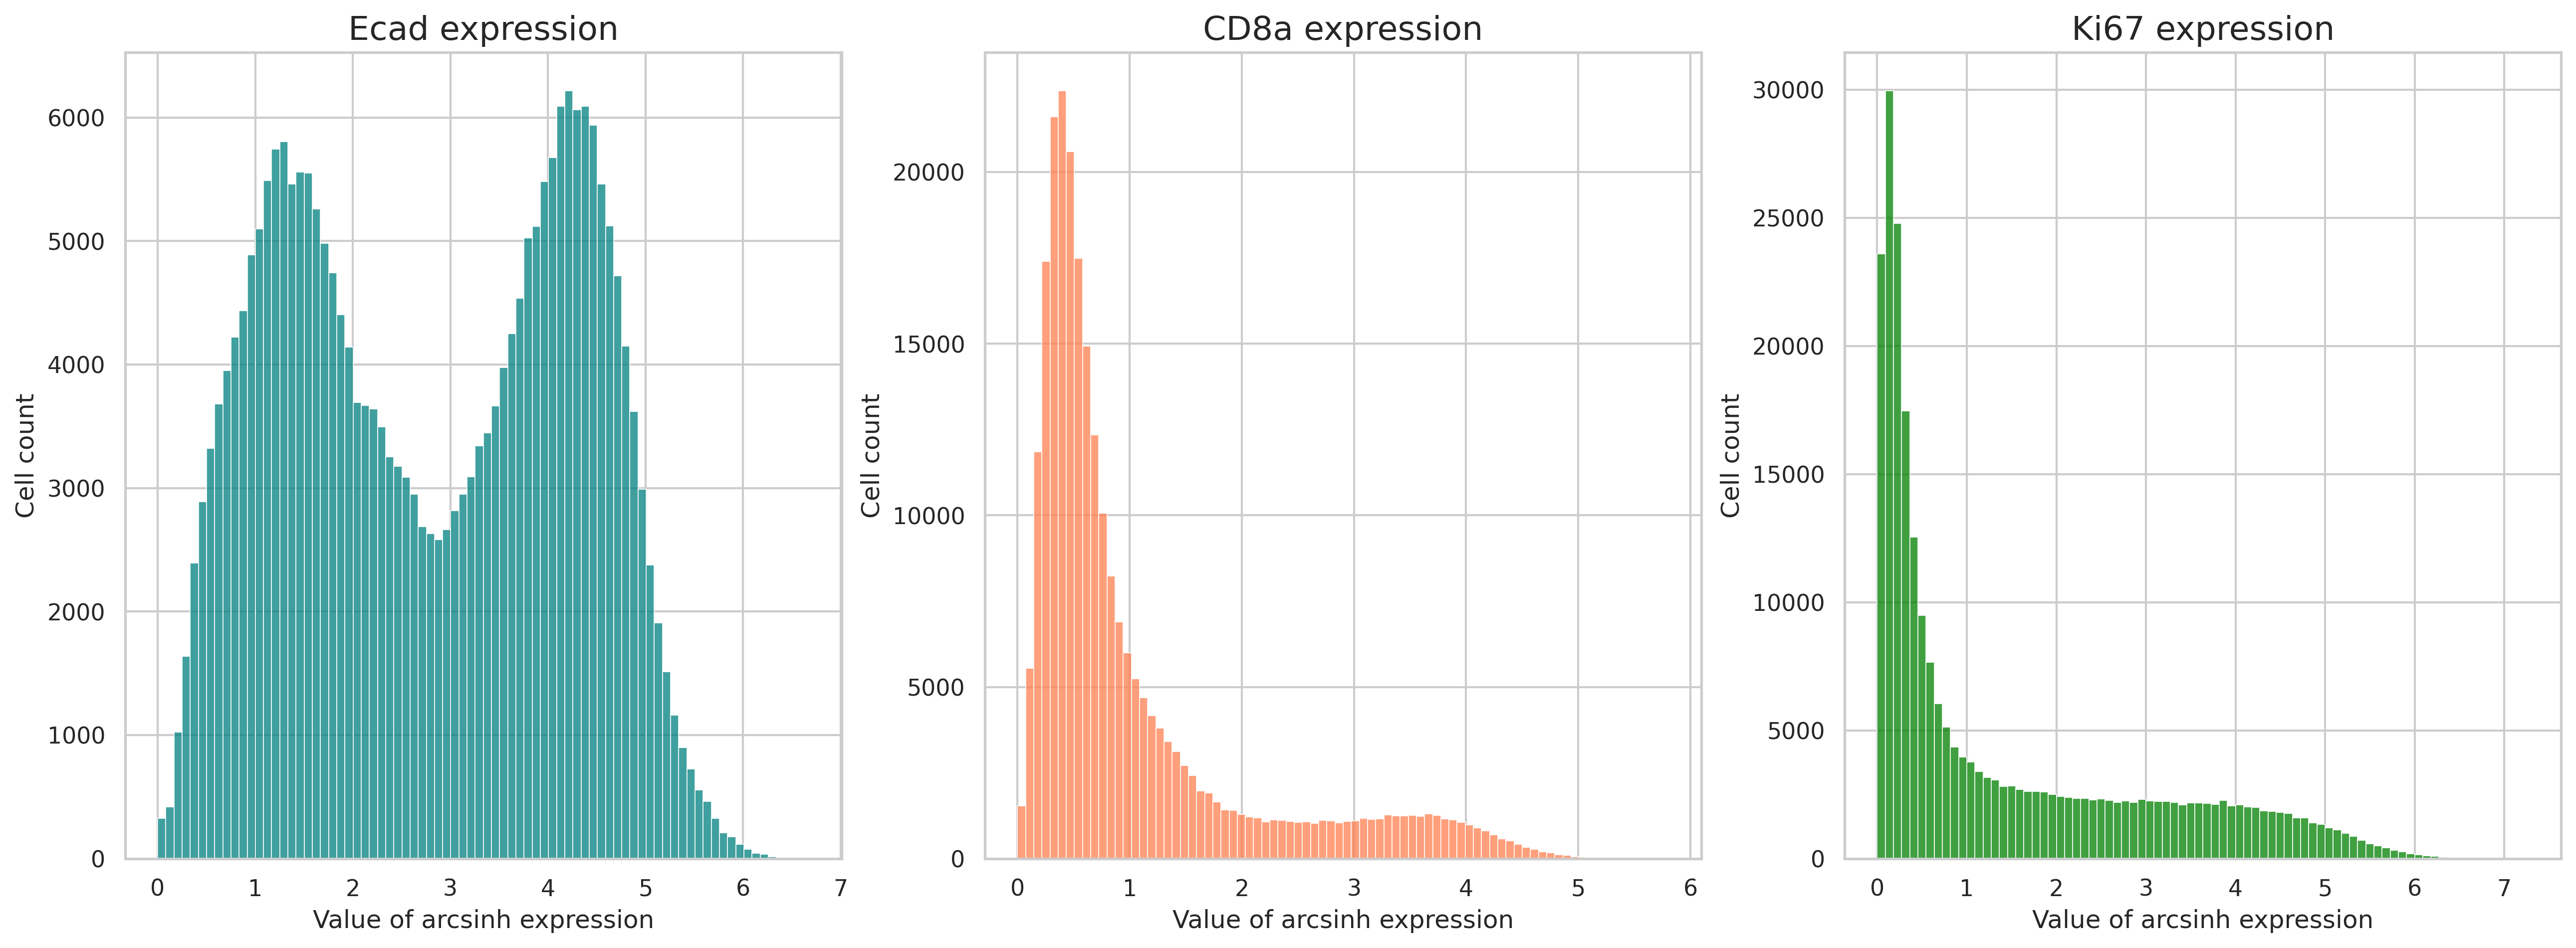

In [42]:
markers = ["Ecad", "CD8a", "Ki67"]
colors = ["teal", "coral", "green"]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Iterate over markers and axes
for i, marker in enumerate(markers):
    ax = axes[i]
    col = np.where(adata.var['marker'] == marker)[0][0]
    expr = adata.layers['exprs_arcsinh'][:, col]
    sns.histplot(expr, bins=80, ax=ax, color=colors[i])

    ax.set_title(f"{marker} expression", fontsize=16)
    ax.set_xlabel("Value of arcsinh expression", fontsize=12)
    ax.set_ylabel("Cell count", fontsize=12)



**Panel 1:**

Możemy zauważyć, że dla markeru Ecad dane rozłożone są w sposób bimodalny (dwa rożne piki). Mówi to nam, że dla tego markeru istnieje podział na dwie różne względem siebie grupy komórkowe - takie, które praktycznie nie wykazują ekspresji tego genu i takie dla, których jest bardzo charakterystyczna co pozwala nam zastosować go do potencjalnego odróżnienia komórek nowotworowych od zdrowych.

**Panel 2 i 3:**

W tym przypadku mamy do czynienia z rozkładem unimodalnym co można interpretować jako to, że marker sam w sobie nie definiuje nam konkretnego typu komórkowego. 

## Task 3

**Goal:** Quantify how tumour-cell fraction and key tumour marker expression vary by cancer type, and
determine whether indications cluster by their tumour molecular profile.

**Deliverables:** 
1. A barplot of Tumor cell fraction per indication (sorted descending).
2. A heatmap of z-scored Ecad, CarbonicAnhydrase, and Ki67 expression in Tumor cells per indica-
tion, with a dendrogram showing hierarchical clustering of indications.
3. Two sentences: which indications cluster together, and what does the shared marker profile suggest
biologically?

In [18]:
tumor_frac = (
    adata.obs
    .groupby("Indication", observed=True)["celltypes"] # grupujemy po indikacji i subsetujemy kolumnę z typami komórek
    .apply(lambda s: (s == "Tumor").mean()) # dla każdej grupy obliczamy średnią, która odpowiada frakcji komórek nowotworowych
    .rename("Tumor_fraction") 
    .sort_values(ascending=False)
    .reset_index()
)

tumor_frac

,Indication,Tumor_fraction
0,HN,0.678782
1,GI,0.535670
2,THOR,0.531939
3,BREAS,0.516139
4,GU,0.455558


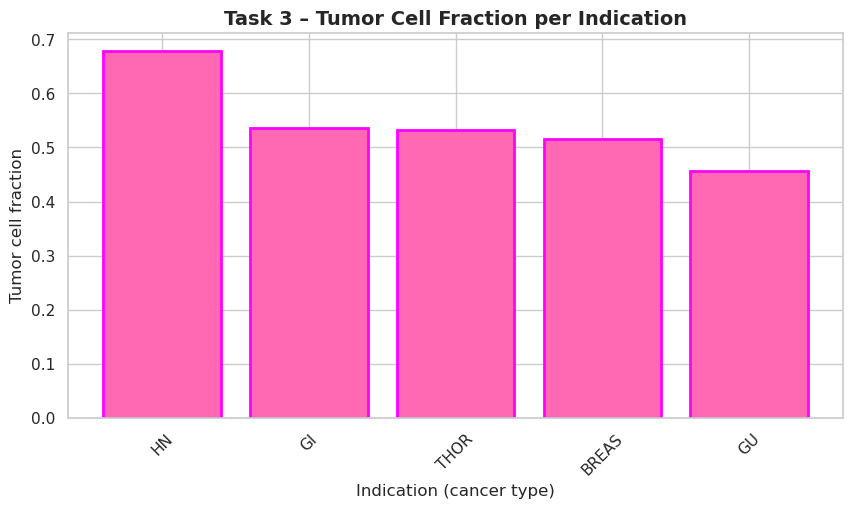

In [19]:
# Wykre słupkowy frakcji komórek nowotworowych dla każdej indikacji
plt.rcParams['figure.dpi'] = 100
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(
    tumor_frac["Indication"],
    tumor_frac["Tumor_fraction"],
    color="hotpink",
    edgecolor="magenta",
    linewidth=2
)
ax1.set_xlabel("Indication (cancer type)", fontsize=12)
ax1.set_ylabel("Tumor cell fraction", fontsize=12)
ax1.set_title("Task 3 – Tumor Cell Fraction per Indication", fontsize=14, fontweight="bold")
ax1.tick_params(axis="x", rotation=45)

In [20]:
# obliczenie średniej ekspresji arcsinh dla trzech markerów w komórkach nowotworowych
MARKERS = ["Ecad", "CarbonicAnhydrase", "Ki67"]

# subsetujemy tylko komórki nowotworowe
adata_tumor = adata[adata.obs["celltypes"] == "Tumor"].copy() # nie chcemy nic popsuć

# dataframe z arcsinh ekspresją markerów 
expr_df = pd.DataFrame(
    adata_tumor.layers["exprs_arcsinh"],
    index=adata_tumor.obs_names,
    columns=adata_tumor.var["marker"].values
)

# checmy tylko te 3 markery, które nas interesują
expr_df = expr_df[MARKERS]
expr_df["Indication"] = adata_tumor.obs["Indication"].values

# średnia ekspresja 3 markerów w komórkach nowotworowych dla każdej indikacji
marker_df = (
    expr_df
    .groupby("Indication", observed=True)[MARKERS]
    .mean()
)

marker_df

,Ecad,CarbonicAnhydrase,Ki67
Indication,,,
BREAS,4.335988,1.909136,2.231839
GI,3.863488,1.557918,2.169100
GU,1.495726,3.894414,0.389315
HN,4.321932,2.436929,2.535008
THOR,3.474983,1.451339,1.916187


In [23]:
# klastrowanie hierarchiczne
linkage = hierarchy.linkage(marker_df, method="ward")

# z-score normalizacja
zdf = pd.DataFrame(
    zscore(marker_df.values, axis=0),
    index=marker_df.index,
    columns=marker_df.columns
)

Text(0.5, 1.02, 'Task 3 – Z-scored Marker Expression in Tumor Cells\n(Ward hierarchical clustering of indications)')

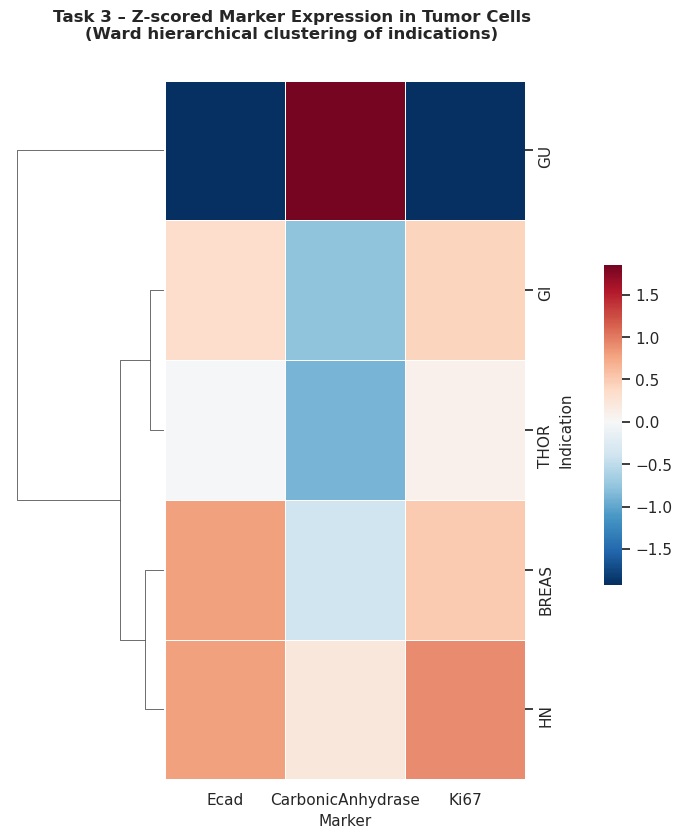

In [24]:
plt.rcParams['figure.dpi'] = 100

cg = sns.clustermap(
    zdf,
    row_linkage=linkage,
    col_cluster=False,          # keep Ecad → CarbonicAnhydrase → Ki67 order
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    figsize=(6, 8),
    dendrogram_ratio=(0.3, 0.05),
    cbar_pos=(1.02, 0.3, 0.03, 0.4),
)
cg.ax_heatmap.set_xlabel("Marker", fontsize=11)
cg.ax_heatmap.set_ylabel("Indication", fontsize=11)
cg.fig.suptitle(
    "Task 3 – Z-scored Marker Expression in Tumor Cells\n(Ward hierarchical clustering of indications)",
    y=1.02, fontsize=12, fontweight="bold")

## Task 4

**Goal:** Select one image using a quantitative criterion and visualise both the spatial cell-type organisation
and the within-image heterogeneity of a biologically relevant marker

**Deliverable:**
1. Your chosen criterion (including the minimum Tumor cell filter used), the selected image ID, and
the criterion value.
2. A two-panel figure for that image: left - scatter plot coloured by cell type; right - scatter plot of
all cells coloured by the continuous expression of your chosen marker.
3. One sentence comparing the two panels: does the marker's spatial pattern align with or deviate
from the cell-type boundaries?

For the criterion i've used CD8/Tumor cell ratio. I also limit images to those that have more Tumor cells than CD8 cells.

In [5]:
min_tumor = 500
results=[]

for image in adata.obs["image"].unique():

    cell_counts = adata[adata.obs["image"]==image].obs["celltypes"].value_counts()

    if "CD8" not in cell_counts or "Tumor" not in cell_counts:
        continue

    cd8_count = cell_counts["CD8"]
    tumor_count = cell_counts["Tumor"]

    # filtering out small tumor sized images and images where most of cells are CD8 cells.
    if tumor_count < 1000 or cd8_count > tumor_count:
        continue

    criterion = np.round(cd8_count/tumor_count, 2)

    results.append({"image": image, "criterion_value": criterion})

df = pd.DataFrame(results)
df = df.sort_values(by="criterion_value", ascending=False)
df.head(1)

,image,criterion_value
56,IMMUcan_Batch20220609_S-220218-00008_003.tiff,0.83


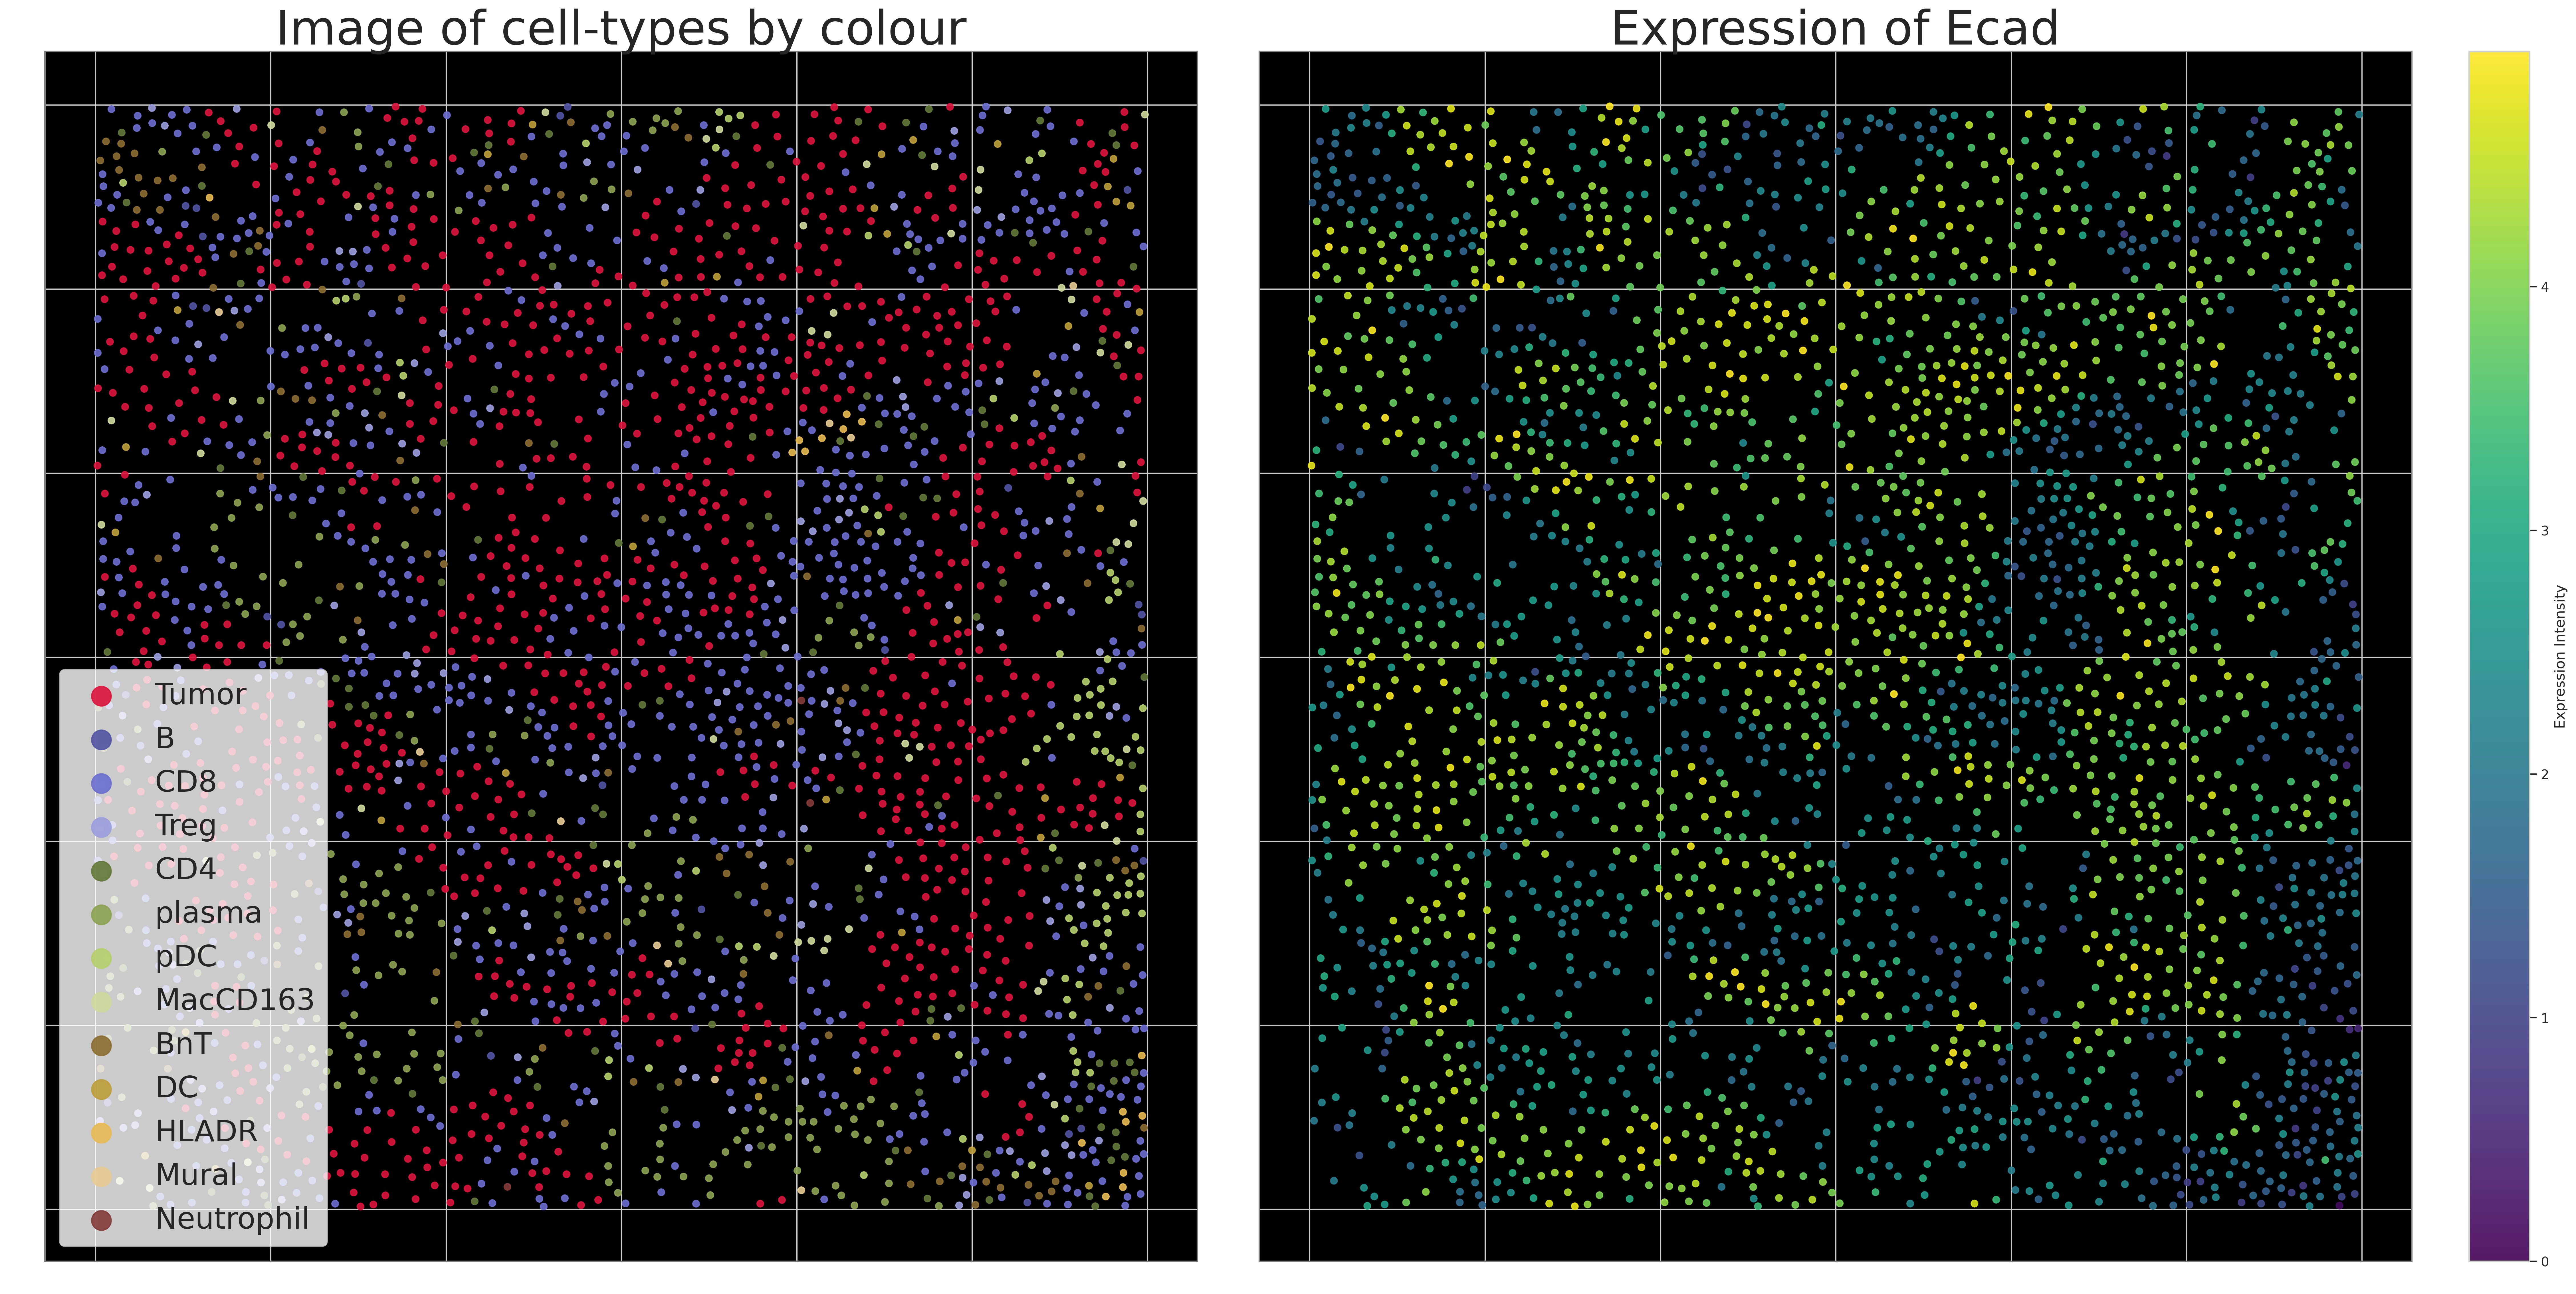

In [44]:
IMAGE_ID = df.head(1)["image"].values[0]
adata_img = adata[adata.obs["image"] == IMAGE_ID].copy()
coords = adata_img.obsm["spatial"]
marker_to_map = "Ecad"

# create two axes
fig, axes = plt.subplots(1, 2, figsize=(30, 15), constrained_layout=True)

# black background for better visualization
for ax in axes:
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('grey')

ax1 = axes[0]

# Choose unique celltypes and colors for it.
celltypes = adata_img.obs["celltypes"].unique()

# color palette
cmap = plt.get_cmap("tab20b")
color_dict = {
    ct: cmap(i) 
    for i, ct in enumerate(celltypes)
}

# Make sure tumor is different and vivid color.
color_dict["Tumor"] = "crimson"

# color each celltype
for ct in celltypes:
    m = adata_img.obs['celltypes'] == ct
    ax1.scatter(coords[m, 0], coords[m, 1], s=30,
                 alpha=0.9, color=color_dict[ct], label=ct)

ax1.set_title("Image of cell-types by colour", fontsize=40)
ax1.invert_yaxis()
ax1.legend(markerscale=3, fontsize=25)

# right plot
ax2 = axes[1]

# color each cell by it's expression of selected marker
m_idx = np.where(adata_img.var['marker'] == marker_to_map)[0]
marker_expr = adata_img.layers['exprs_arcsinh'][:, m_idx[0]]
sc = ax2.scatter(
            coords[:, 0], coords[:, 1],
            c=marker_expr, cmap='viridis',
            s=30, alpha=0.9, rasterized=True,
            vmin=0, vmax=np.percentile(marker_expr, 99)
        )

ax2.set_title(f"Expression of Ecad", fontsize=40)
ax2.invert_yaxis()
plt.colorbar(sc, ax=ax2, label='Expression Intensity')
plt.show()

Możemy zauważyć, że ekspresja naszego markeru "Ecad" w bardzo dobry sposób odróżnia komórki nowotworowe od innych typów (widać w tych samych miejscach co "tumor" cell zwiększoną ekspresję), wiec tak sygnał tego markera pozostaje zgodny z granicami typów komórkowych, aczkolwiek są miejsca gdzie radzi sobie on gorzej.